# Task 3: Baseline Model Training

This notebook demonstrates the process of building and evaluating baseline machine learning models to predict passenger satisfaction. We will compare Logistic Regression, Random Forest, and HistGradientBoosting.

## 1. Imports and Configuration

First, we import the necessary libraries and define the configuration for data paths and figure storage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Configuration
DATA_PATH = '../../data/processed/antigravity_clean.csv'
FIGURES_DIR = '../../figures/antigravity/'
os.makedirs(FIGURES_DIR, exist_ok=True)

figure_counter = 1

def save_and_show(fig, name):
    global figure_counter
    filename = f"{figure_counter:02d}_{name}.png"
    filepath = os.path.join(FIGURES_DIR, filename)
    fig.savefig(filepath, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Figure saved to: {filepath}")
    figure_counter += 1

## 2. Data Loading & Initial Inspection

We load the cleaned dataset and take a quick look at its structure.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (129880, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 3. Preprocessing

In this step, we:
- Remove the `id` column.
- Handle missing values by imputing with the median (numerical) or mode (categorical).
- Encode the target variable (`satisfaction`).
- Encode categorical features.

In [3]:
# Remove 'id' column
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Handle missing values
nan_cols = df.columns[df.isna().any()].tolist()
for col in nan_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode target
le_target = LabelEncoder()
df['satisfaction'] = le_target.fit_transform(df['satisfaction']) # 0: neutral or dissatisfied, 1: satisfied

# Encode categorical features
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


## 4. Train-Test Split

We split the data into training (80%) and testing (20%) sets using a random state of 42 for reproducibility.

In [4]:
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (103904, 22)
Test set size: (25976, 22)


## 5. Model Training & Evaluation

We train three models and evaluate them using Accuracy, F1 Score, and ROC AUC.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_test": y_test,
        "y_proba": y_proba
    }

for name, res in results.items():
    print(f"\n{name} Results:")
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(f"F1 Score: {res['f1']:.4f}")
    print(f"ROC AUC: {res['roc_auc']:.4f}")

Training Logistic Regression...
Training Random Forest...
Training HistGradientBoosting...

Logistic Regression Results:
Accuracy: 0.8761
F1 Score: 0.8554
ROC AUC: 0.9257

Random Forest Results:
Accuracy: 0.9625
F1 Score: 0.9562
ROC AUC: 0.9937

HistGradientBoosting Results:
Accuracy: 0.9633
F1 Score: 0.9572
ROC AUC: 0.9948


## 6. Visualizations

Finally, we visualize the model performance comparison and the ROC curves.

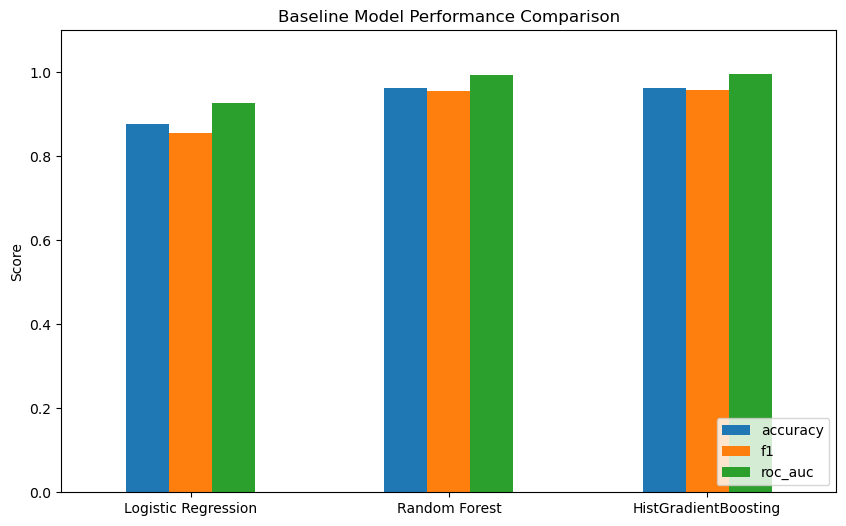

Figure saved to: ../../figures/antigravity/01_model_performance_comparison.png


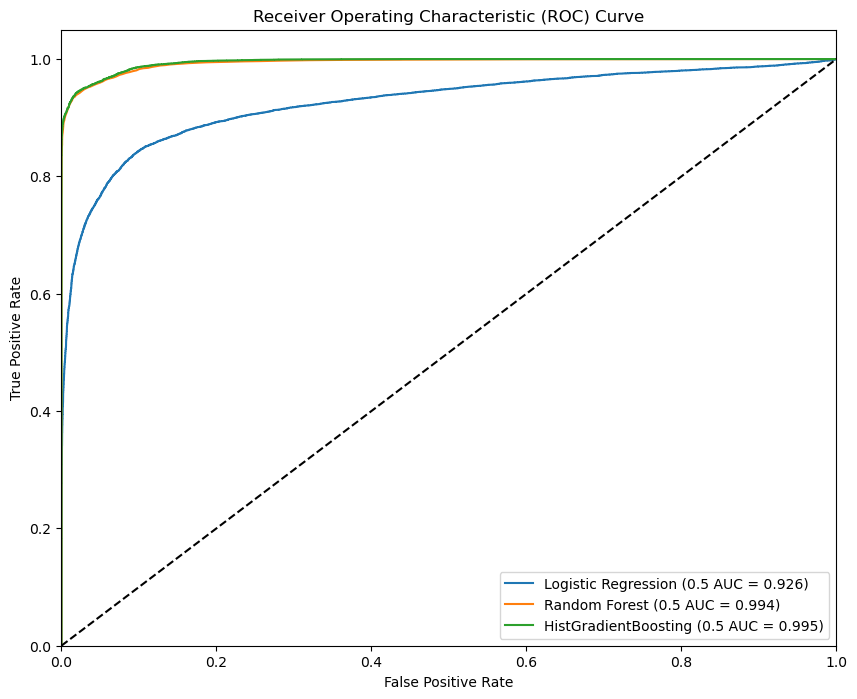

Figure saved to: ../../figures/antigravity/02_roc_curves.png


In [6]:
# 1. Performance Comparison Bar Chart
metrics_df = pd.DataFrame(results).T[['accuracy', 'f1', 'roc_auc']]
fig1, ax1 = plt.subplots(figsize=(10, 6))
metrics_df.plot(kind='bar', ax=ax1)
ax1.set_title("Baseline Model Performance Comparison")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.1)
ax1.legend(loc='lower right')
plt.xticks(rotation=0)
save_and_show(fig1, "model_performance_comparison")

# 2. ROC Curves
fig2, ax2 = plt.subplots(figsize=(10, 8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_proba'])
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, label=f'{name} (0.5 AUC = {roc_auc:.3f})')
    
ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver Operating Characteristic (ROC) Curve')
ax2.legend(loc="lower right")
save_and_show(fig2, "roc_curves")